# Task 1 — Табличная классификация клинических рисков (улучшенное решение)

**Цели:**
1. EDA: распределения, пропуски, корреляции, баланс классов, PCA.
2. Классификатор высокого сердечно-сосудистого риска (`prediction`) — честный пайплайн без утечек, сравнение моделей кросс-валидацией, подбор гиперпараметров, выбор порога.
3. Оценка на отложенной выборке: Accuracy, Recall, Specificity, Precision, F1, ROC-AUC, матрица ошибок, ROC-кривая.
4. Нечёткий KNN (Keller et al., 1985) для пограничной глюкозы 5.4–6.5 ммоль/л: степени принадлежности, скор риска, неопределённость.
5. Прогнозы для `dataset/task1/test_features.csv` → `outputs/task1_predictions.csv`.

**Главные отличия от базового ноутбука (`vanilla-code`):**
- `StandardScaler` и импьютер в базовой версии обучались на **всех** данных до разбиения → утечка информации из валидации. Здесь вся предобработка живёт внутри `sklearn.Pipeline` и обучается только на train-фолдах.
- Базовая SVM использовала 8 признаков и игнорировала **возраст** (самый сильный признак, r≈0.49), глюкозу, пол, СКФ. Здесь используются все клинические признаки.
- Столбцы `Статус_глюкозы` и `Доклинический_риск` — это **другие целевые переменные**, они исключены из признаков (хотя и присутствуют в `test_features.csv`).
- Пропуски: `IterativeImputer` (многомерная регрессионная импутация) + индикаторы пропусков вместо заполнения средним.
- Сравниваются 4 семейства моделей (LogReg, SVM, RandomForest, HistGradientBoosting) с подбором гиперпараметров; порог классификации подбирается по out-of-fold предсказаниям на train, а не на отложенной выборке.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, GridSearchCV, cross_val_predict,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, brier_score_loss, precision_recall_curve,
    log_loss, classification_report,
)

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Загрузка данных

In [2]:
repo_root = Path.cwd()
if repo_root.name in {'vanilla-code', 'your-sollution', 'your_solution'}:
    repo_root = repo_root.parent

train_path = repo_root / 'dataset' / 'task1' / 'train.csv'
test_features_path = repo_root / 'dataset' / 'task1' / 'test_features.csv'

if train_path.exists() and test_features_path.exists():
    df = pd.read_csv(train_path)
    test_features = pd.read_csv(test_features_path)
else:  # запуск вне репозитория (Colab)
    base = ('https://github.com/AI-is-out-there/check-your-biomed-datascience-skills-review/'
            'raw/refs/heads/main/dataset/task1')
    df = pd.read_csv(f'{base}/train.csv')
    test_features = pd.read_csv(f'{base}/test_features.csv')

fig_dir = repo_root / 'outputs' / 'task1_figures'
fig_dir.mkdir(parents=True, exist_ok=True)


def save(fig, name):
    fig.savefig(fig_dir / name, dpi=110, bbox_inches='tight')


TARGET = 'prediction'
OTHER_TARGETS = ['Статус_глюкозы', 'Доклинический_риск']
ID = 'patient_id'
FEATURES = [c for c in df.columns if c not in [ID, TARGET, *OTHER_TARGETS]]
BINARY = ['Пол_мужской', 'Курение']
NUMERIC = [c for c in FEATURES if c not in BINARY]

print('train:', df.shape, ' test:', test_features.shape)
print('Признаки модели (%d):' % len(FEATURES), FEATURES)
assert set(FEATURES) <= set(test_features.columns)
assert test_features[ID].is_unique and df[ID].is_unique
assert not set(df[ID]) & set(test_features[ID]), 'пересечение пациентов train/test'
df.head()

train: (800, 19)  test: (200, 18)
Признаки модели (15): ['Возраст', 'Пол_мужской', 'ИМТ', 'Окружность_талии_см', 'САД_мм_рт_ст', 'ДАД_мм_рт_ст', 'Пульсовое_давление', 'Глюкоза_натощак_ммоль_л', 'HbA1c_%', 'ЛПНП_ммоль_л', 'ЛПВП_ммоль_л', 'Триглицериды_ммоль_л', 'СКФ_мл_мин', 'Курение', 'Физическая_активность_мин_нед']


,patient_id,Возраст,Пол_мужской,ИМТ,Окружность_талии_см,САД_мм_рт_ст,ДАД_мм_рт_ст,Пульсовое_давление,Глюкоза_натощак_ммоль_л,HbA1c_%,ЛПНП_ммоль_л,ЛПВП_ммоль_л,Триглицериды_ммоль_л,СКФ_мл_мин,Курение,Физическая_активность_мин_нед,prediction,Статус_глюкозы,Доклинический_риск
0,1,41,1,24.240,81.040,113.190,62.540,50.650,4.595,4.650,NaN,NaN,1.379,115.520,0,165.800,0,0,0
1,4,53,0,19.840,73.440,119.750,71.590,48.150,4.431,5.080,2.268,2.022,1.467,93.390,0,248.100,0,0,0
2,5,53,1,24.280,82.060,127.070,70.340,56.730,4.997,5.040,2.459,1.325,0.967,88.410,0,230.500,0,0,0
3,6,60,1,25.190,91.890,116.980,82.000,34.980,5.491,5.000,3.700,0.722,1.505,91.060,1,132.500,1,0,0
4,7,59,1,24.450,84.070,129.120,82.700,46.420,6.456,4.800,3.960,1.406,2.274,89.740,1,177.400,1,2,0


## 2. EDA: пропуски, баланс классов, распределения, корреляции

In [3]:
miss = pd.DataFrame({
    'train, пропусков': df[FEATURES].isna().sum(),
    'train, %': df[FEATURES].isna().mean() * 100,
    'test, пропусков': test_features[FEATURES].isna().sum(),
}).query('`train, пропусков` > 0 or `test, пропусков` > 0')
display(miss)

# Зависит ли пропуск от целевой переменной? (если да — сам факт пропуска информативен)
for col in miss.index:
    rate = df.groupby(df[col].isna())[TARGET].mean()
    print(f'{col:28s} доля высокого риска: есть значение={rate.get(False, np.nan):.2f}, '
          f'пропуск={rate.get(True, np.nan):.2f}')

display(df[FEATURES].describe().T)

,"train, пропусков","train, %","test, пропусков"
ЛПНП_ммоль_л,35,4.375,10
ЛПВП_ммоль_л,45,5.625,11
Триглицериды_ммоль_л,46,5.750,15
СКФ_мл_мин,47,5.875,14


ЛПНП_ммоль_л                 доля высокого риска: есть значение=0.18, пропуск=0.11
ЛПВП_ммоль_л                 доля высокого риска: есть значение=0.18, пропуск=0.16
Триглицериды_ммоль_л         доля высокого риска: есть значение=0.18, пропуск=0.22
СКФ_мл_мин                   доля высокого риска: есть значение=0.18, пропуск=0.19


,count,mean,std,min,25%,50%,75%,max
Возраст,800.000,52.256,7.563,40.000,45.000,53.000,59.000,65.000
Пол_мужской,800.000,0.446,0.497,0.000,0.000,0.000,1.000,1.000
ИМТ,800.000,23.568,3.229,16.000,21.120,23.595,26.035,33.890
Окружность_талии_см,800.000,86.178,6.026,68.860,81.968,86.160,90.505,104.630
САД_мм_рт_ст,800.000,114.084,11.162,90.000,106.627,114.475,121.957,147.970
ДАД_мм_рт_ст,800.000,70.346,7.099,50.000,65.450,70.435,75.028,90.620
Пульсовое_давление,800.000,43.738,10.345,9.060,36.847,43.895,50.398,73.950
Глюкоза_натощак_ммоль_л,800.000,5.070,0.769,3.500,4.534,5.006,5.603,7.348
HbA1c_%,800.000,5.019,0.365,4.000,4.780,5.010,5.280,6.020
ЛПНП_ммоль_л,765.000,2.983,0.643,1.207,2.556,2.987,3.415,5.115


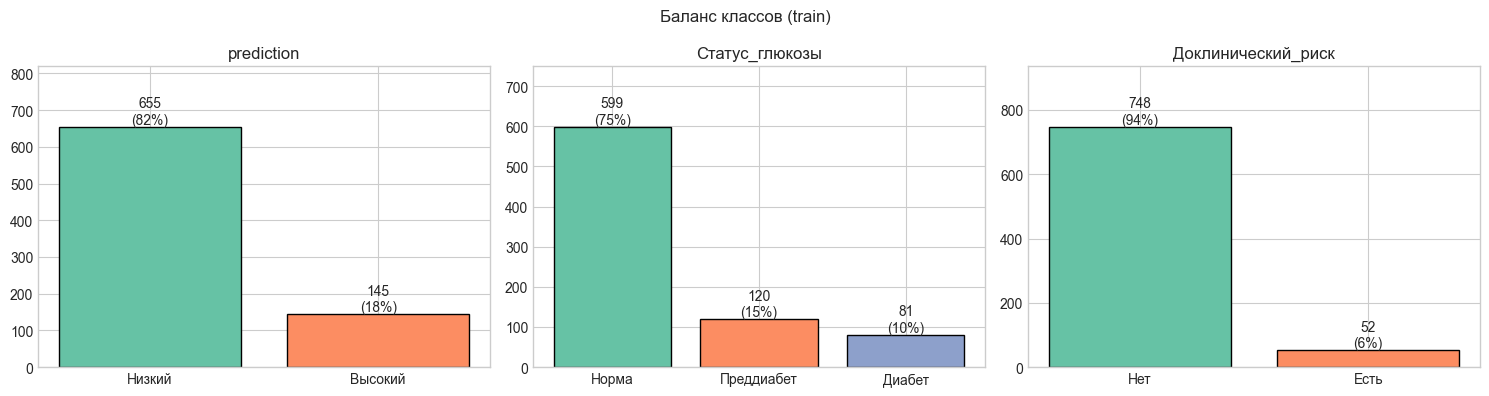

Дисбаланс prediction: 18.1% положительного класса → нужны class_weight / выбор порога и метрики помимо Accuracy.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = {TARGET: ['Низкий', 'Высокий'],
          'Статус_глюкозы': ['Норма', 'Преддиабет', 'Диабет'],
          'Доклинический_риск': ['Нет', 'Есть']}
for ax, col in zip(axes, [TARGET, *OTHER_TARGETS]):
    vc = df[col].value_counts().sort_index()
    ax.bar(labels[col], vc.values, color=sns.color_palette('Set2', len(vc)), edgecolor='black')
    for i, v in enumerate(vc.values):
        ax.text(i, v, f'{v}\n({v / len(df):.0%})', ha='center', va='bottom')
    ax.set_title(col)
    ax.set_ylim(0, vc.max() * 1.25)
fig.suptitle('Баланс классов (train)')
plt.tight_layout(); save(fig, '01_class_balance.png'); plt.show()
print(f'Дисбаланс prediction: {df[TARGET].mean():.1%} положительного класса → '
      'нужны class_weight / выбор порога и метрики помимо Accuracy.')

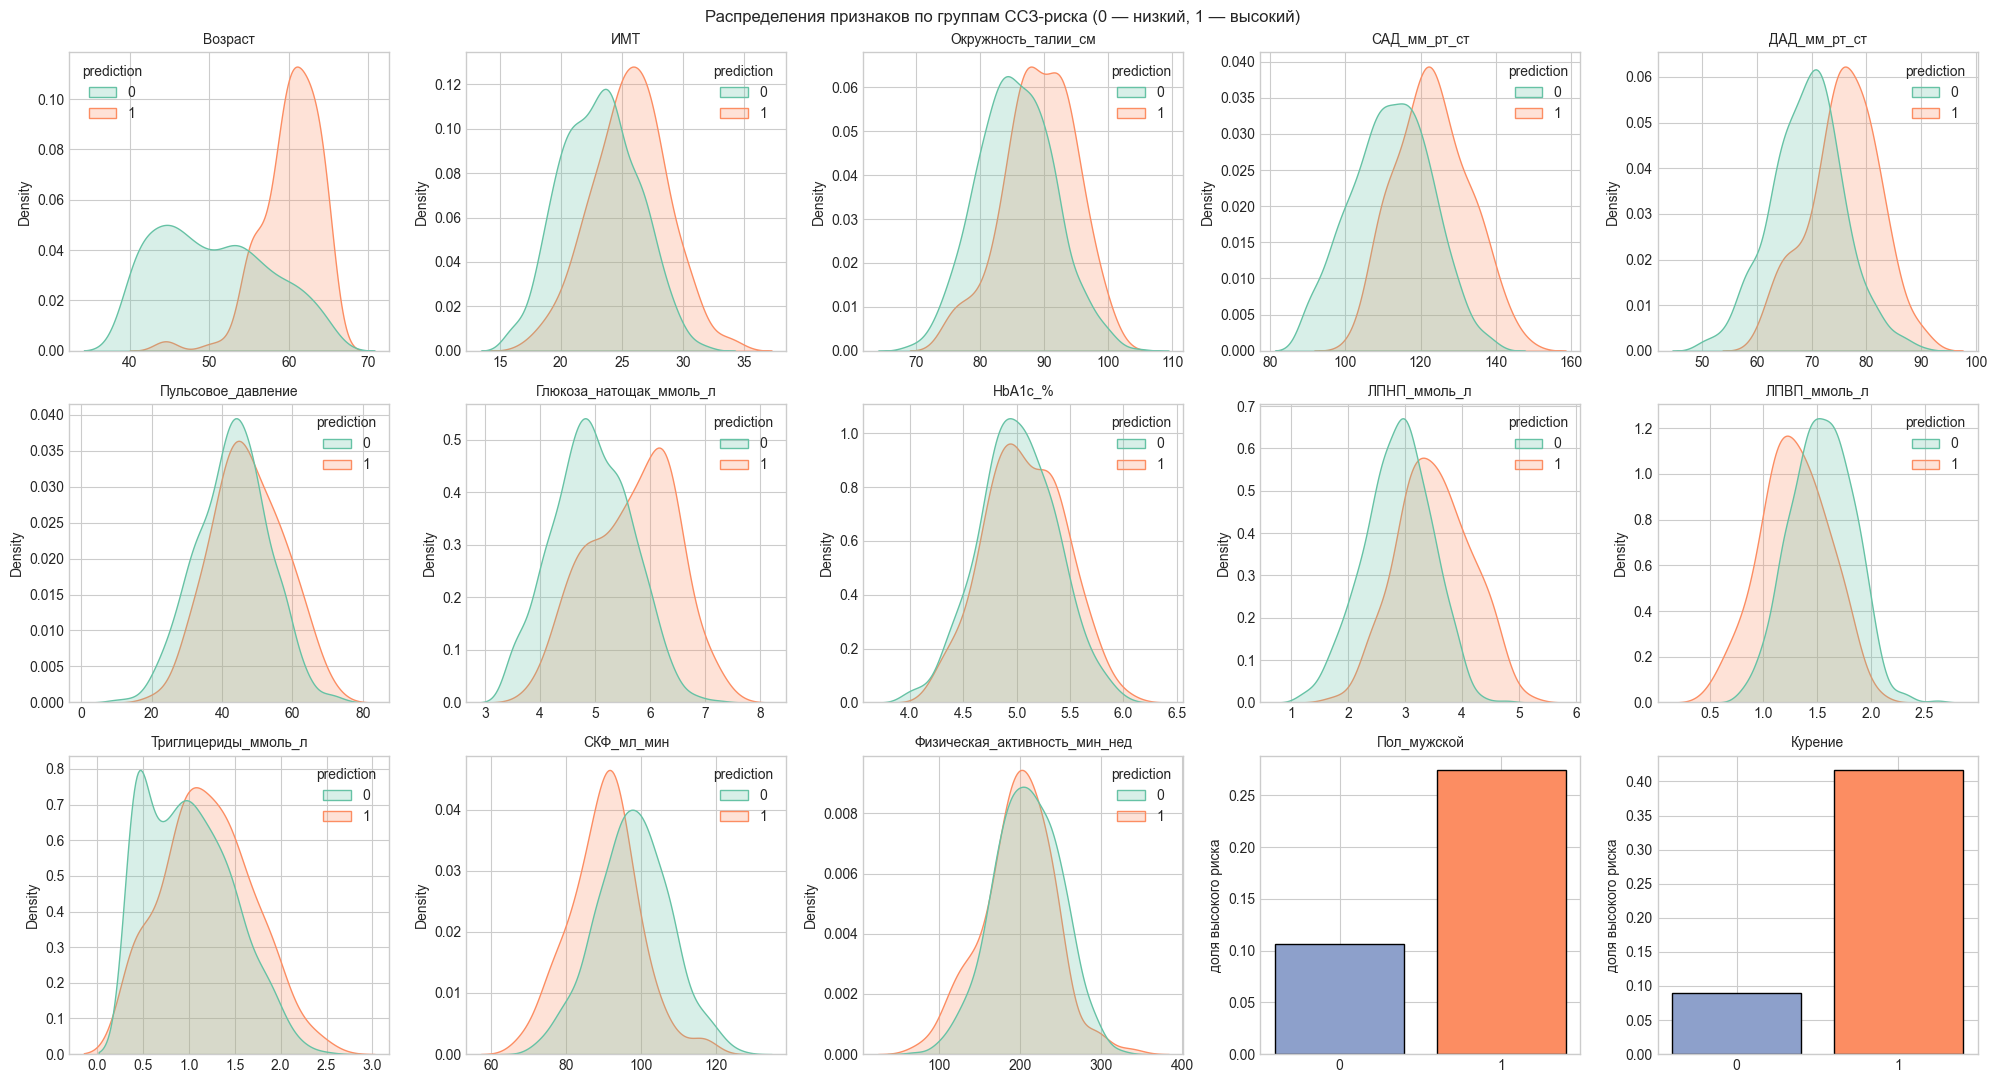

In [5]:
fig, axes = plt.subplots(3, 5, figsize=(20, 11))
for ax, col in zip(axes.flat, NUMERIC + BINARY):
    if col in BINARY:
        ct = pd.crosstab(df[col], df[TARGET], normalize='index')[1]
        ax.bar(ct.index.astype(str), ct.values, color=['#8da0cb', '#fc8d62'], edgecolor='black')
        ax.set_ylabel('доля высокого риска')
    else:
        sns.kdeplot(data=df, x=col, hue=TARGET, common_norm=False, fill=True, ax=ax,
                    palette={0: '#66c2a5', 1: '#fc8d62'}, warn_singular=False)
    ax.set_title(col, fontsize=10); ax.set_xlabel('')
for ax in axes.flat[len(NUMERIC + BINARY):]:
    ax.axis('off')
fig.suptitle('Распределения признаков по группам ССЗ-риска (0 — низкий, 1 — высокий)')
plt.tight_layout(); save(fig, '02_feature_distributions.png'); plt.show()

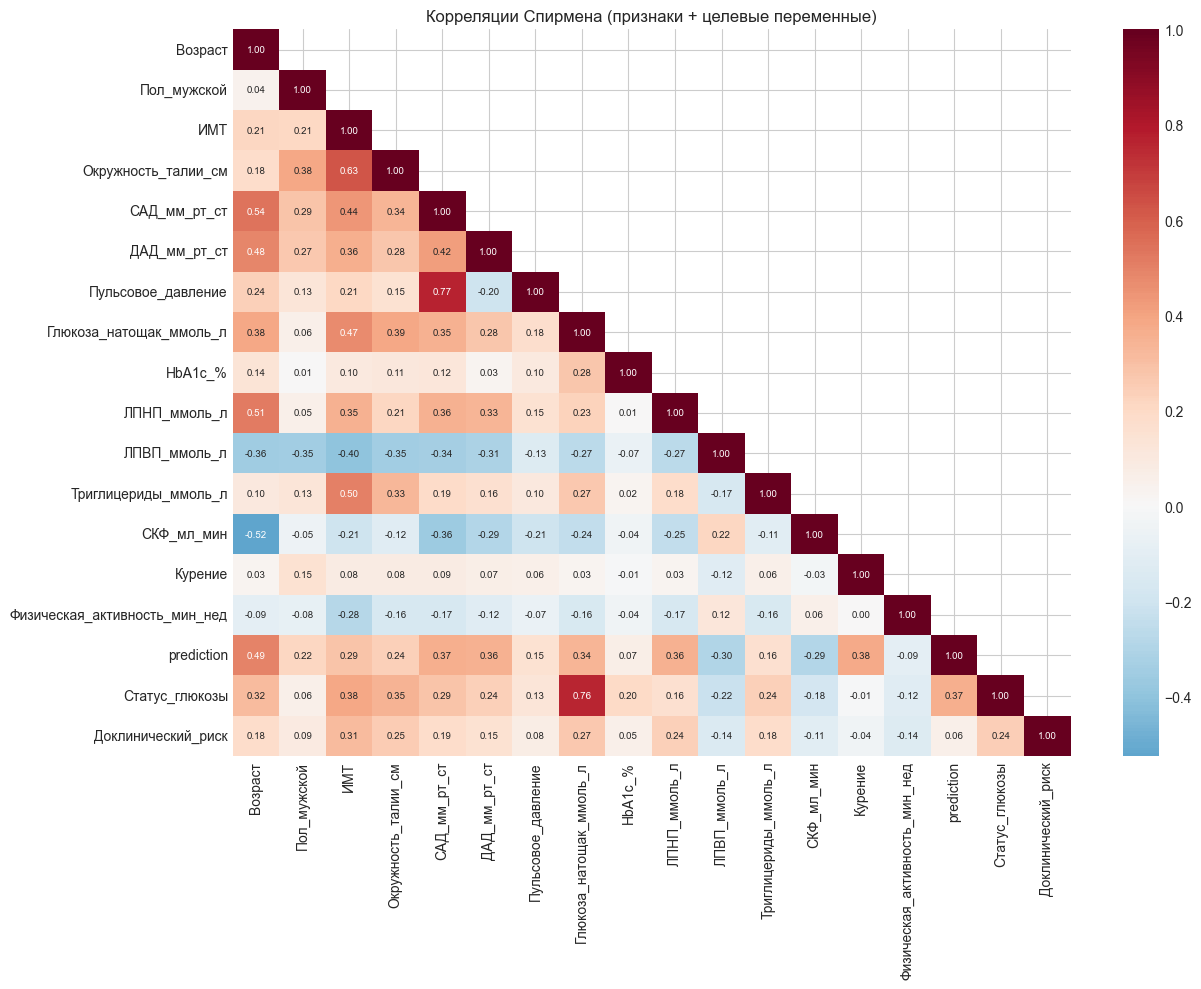

Корреляция признаков с prediction:


,prediction
Возраст,0.494
Курение,0.381
САД_мм_рт_ст,0.366
ЛПНП_ммоль_л,0.356
ДАД_мм_рт_ст,0.356
Глюкоза_натощак_ммоль_л,0.337
ЛПВП_ммоль_л,-0.296
СКФ_мл_мин,-0.291
ИМТ,0.288
Окружность_талии_см,0.243


In [6]:
corr = df[FEATURES + [TARGET, *OTHER_TARGETS]].corr(method='spearman')
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=True, fmt='.2f', annot_kws={'size': 7},
            mask=np.triu(np.ones_like(corr, dtype=bool), k=1), ax=ax)
ax.set_title('Корреляции Спирмена (признаки + целевые переменные)')
plt.tight_layout(); save(fig, '03_correlation.png'); plt.show()

print('Корреляция признаков с prediction:')
display(corr[TARGET].drop([TARGET, *OTHER_TARGETS]).sort_values(key=abs, ascending=False).to_frame())

**Наблюдения EDA.** Самые сильные связи с высоким ССЗ-риском: возраст, ЛПНП, САД, курение, глюкоза, ДАД, ИМТ; обратные — ЛПВП и СКФ. Сильно коррелируют между собой ИМТ ↔ окружность талии, САД ↔ пульсовое давление, глюкоза ↔ HbA1c — для линейной модели это мультиколлинеарность (решается L2-регуляризацией). Пропуски есть только в лабораторных показателях (4–6%).

### PCA (обучен на train, только признаки, без целевых)

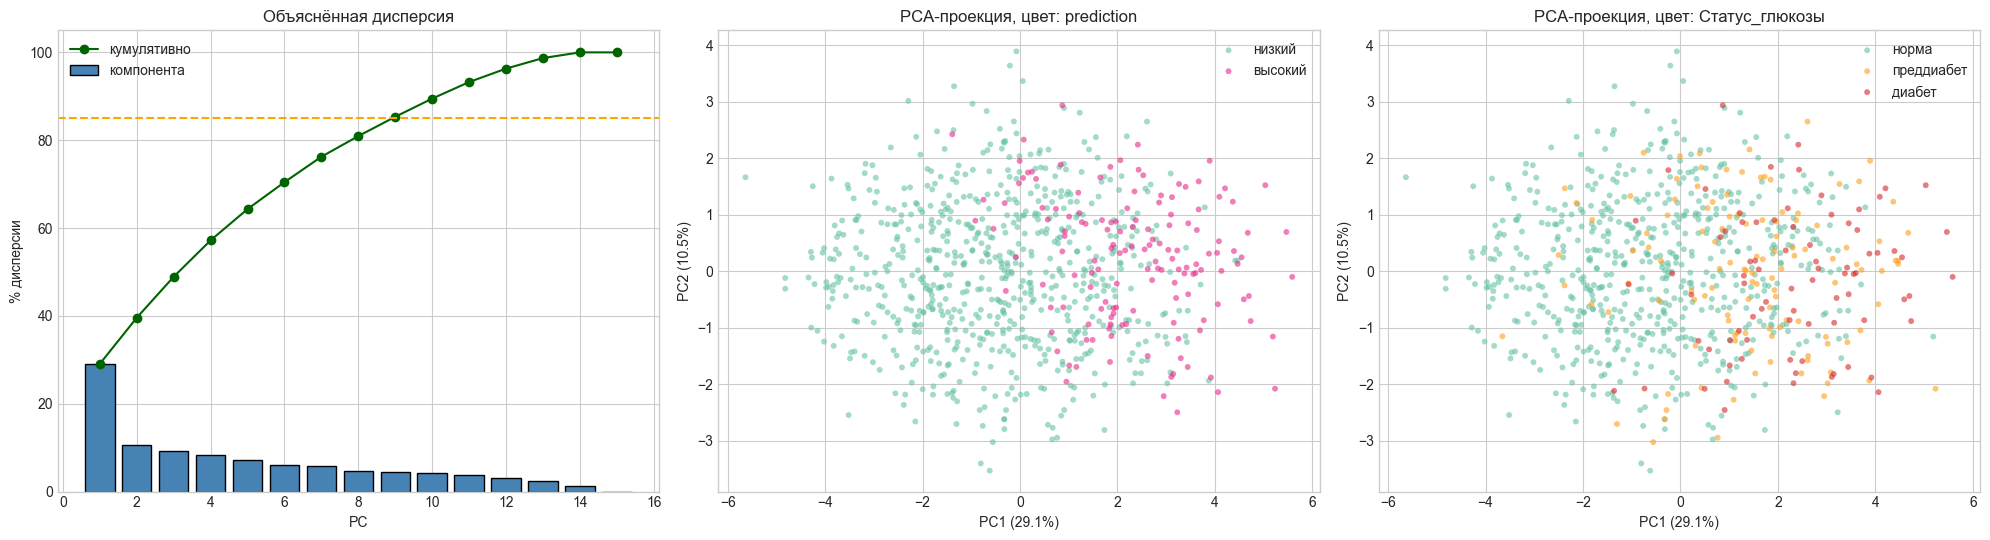

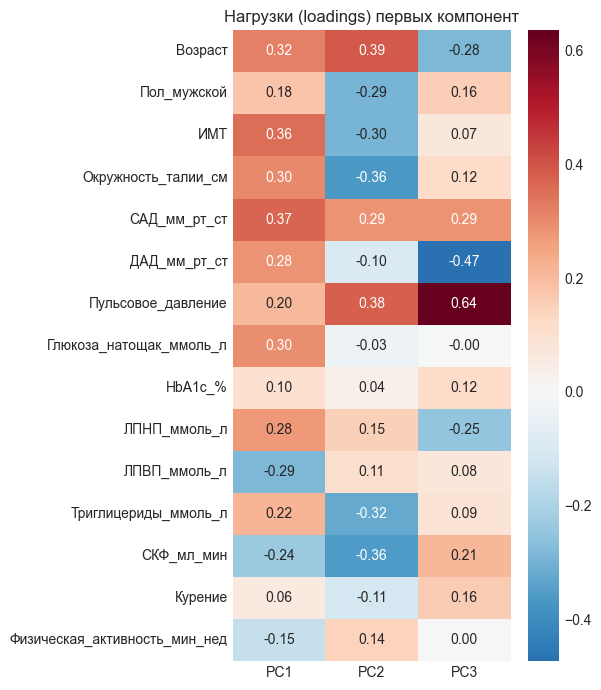

Для 85% дисперсии нужно 9 компонент из 15 — признаки мало избыточны, сжатие PCA для модели не нужно.


In [7]:
pca_pipe = Pipeline([
    ('imp', IterativeImputer(random_state=RANDOM_STATE, max_iter=20)),
    ('sc', StandardScaler()),
    ('pca', PCA(random_state=RANDOM_STATE)),
])
Z = pca_pipe.fit_transform(df[FEATURES])
pca = pca_pipe.named_steps['pca']
evr = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
axes[0].bar(range(1, len(evr) + 1), evr * 100, color='steelblue', edgecolor='black', label='компонента')
axes[0].plot(range(1, len(evr) + 1), np.cumsum(evr) * 100, 'o-', color='darkgreen', label='кумулятивно')
axes[0].axhline(85, ls='--', color='orange'); axes[0].set_xlabel('PC'); axes[0].set_ylabel('% дисперсии')
axes[0].set_title('Объяснённая дисперсия'); axes[0].legend()

for ax, col, pal, names in [
    (axes[1], TARGET, {0: '#66c2a5', 1: '#e7298a'}, {0: 'низкий', 1: 'высокий'}),
    (axes[2], 'Статус_глюкозы', {0: '#66c2a5', 1: '#ff9f1c', 2: '#d62828'}, {0: 'норма', 1: 'преддиабет', 2: 'диабет'}),
]:
    for k, c in pal.items():
        m = df[col].values == k
        ax.scatter(Z[m, 0], Z[m, 1], s=18, alpha=0.6, c=c, label=names[k], edgecolors='none')
    ax.set_xlabel(f'PC1 ({evr[0]:.1%})'); ax.set_ylabel(f'PC2 ({evr[1]:.1%})')
    ax.set_title(f'PCA-проекция, цвет: {col}'); ax.legend()
plt.tight_layout(); save(fig, '04_pca.png'); plt.show()

loadings = pd.DataFrame(pca.components_[:3].T, index=FEATURES, columns=['PC1', 'PC2', 'PC3'])
fig, ax = plt.subplots(figsize=(6, 7))
sns.heatmap(loadings, cmap='RdBu_r', center=0, annot=True, fmt='.2f', ax=ax)
ax.set_title('Нагрузки (loadings) первых компонент')
plt.tight_layout(); save(fig, '05_pca_loadings.png'); plt.show()
print(f'Для 85% дисперсии нужно {np.argmax(np.cumsum(evr) >= 0.85) + 1} компонент из {len(FEATURES)} '
      '— признаки мало избыточны, сжатие PCA для модели не нужно.')

## 3. Классификация ССЗ-риска (`prediction`)

Схема валидации:
1. Стратифицированный split train → **train (80%) / holdout (20%)**. Holdout не трогаем до финальной оценки.
2. На train: сравнение моделей 5-fold стратифицированной CV (× 3 повтора разными сидами для устойчивости), подбор гиперпараметров `GridSearchCV`.
3. Порог выбирается по out-of-fold вероятностям на train.
4. Одна финальная оценка на holdout.
5. Переобучение выбранной конфигурации на всех 800 пациентах → прогноз для test.

In [8]:
X = df[FEATURES]
y = df[TARGET].values
X_tr, X_ho, y_tr, y_ho = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f'train: {len(X_tr)} ({y_tr.mean():.1%} высокого риска) | holdout: {len(X_ho)} ({y_ho.mean():.1%})')


def make_pipe(model):
    return Pipeline([
        ('imp', IterativeImputer(random_state=RANDOM_STATE, max_iter=20, add_indicator=True)),
        ('sc', StandardScaler()),
        ('clf', model),
    ])


candidates = {
    'LogReg (L2, balanced)': LogisticRegression(class_weight='balanced', max_iter=2000, C=1.0),
    'SVM RBF (baseline params)': SVC(kernel='rbf', C=1.0, class_weight='balanced', probability=True,
                                     random_state=RANDOM_STATE),
    'RandomForest (balanced)': RandomForestClassifier(n_estimators=400, min_samples_leaf=3,
                                                      class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=300,
                                                           class_weight='balanced', random_state=RANDOM_STATE),
}

scoring = {'roc_auc': 'roc_auc', 'f1': 'f1', 'recall': 'recall', 'precision': 'precision',
           'bal_acc': 'balanced_accuracy', 'neg_log_loss': 'neg_log_loss'}
rows = []
for name, model in candidates.items():
    res = []
    for seed in range(3):
        cv = StratifiedKFold(5, shuffle=True, random_state=seed)
        res.append(pd.DataFrame(cross_validate(make_pipe(model), X_tr, y_tr, cv=cv, scoring=scoring, n_jobs=-1)))
    res = pd.concat(res)
    rows.append({'Модель': name, **{f'{k} mean': res[f'test_{k}'].mean() for k in scoring},
                 'roc_auc std': res['test_roc_auc'].std()})
cv_table = pd.DataFrame(rows).set_index('Модель').sort_values('roc_auc mean', ascending=False)
cv_table['log_loss mean'] = -cv_table.pop('neg_log_loss mean')
display(cv_table)

train: 640 (18.1% высокого риска) | holdout: 160 (18.1%)


,roc_auc mean,f1 mean,recall mean,precision mean,bal_acc mean,roc_auc std,log_loss mean
Модель,,,,,,,
HistGradientBoosting,0.994,0.950,0.948,0.952,0.969,0.008,0.066
RandomForest (balanced),0.977,0.802,0.759,0.864,0.865,0.011,0.206
"LogReg (L2, balanced)",0.967,0.757,0.885,0.665,0.892,0.014,0.230
SVM RBF (baseline params),0.957,0.741,0.808,0.692,0.863,0.019,0.199


In [9]:
# Подбор гиперпараметров: интерпретируемая логрегрессия, SVM из базового решения и лучший по CV бустинг
cv5 = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
grids = {
    'LogReg': (LogisticRegression(class_weight='balanced', max_iter=5000),
               {'clf__C': [0.01, 0.03, 0.1, 0.3, 1, 3, 10]}),
    'SVM': (SVC(class_weight='balanced', probability=True, random_state=RANDOM_STATE),
            {'clf__kernel': ['rbf', 'linear'], 'clf__C': [0.03, 0.1, 0.3, 1, 3],
             'clf__gamma': ['scale', 0.01, 0.03]}),
    'HistGradientBoosting': (HistGradientBoostingClassifier(class_weight='balanced', random_state=RANDOM_STATE),
                             {'clf__max_depth': [2, 3, 4], 'clf__learning_rate': [0.03, 0.1],
                              'clf__max_iter': [200, 500], 'clf__l2_regularization': [0.0, 1.0]}),
}
searches = {}
for name, (model, grid) in grids.items():
    gs = GridSearchCV(make_pipe(model), grid, scoring='roc_auc', cv=cv5, n_jobs=-1, refit=True)
    gs.fit(X_tr, y_tr)
    searches[name] = gs
    print(f'{name:20s} лучший CV ROC-AUC = {gs.best_score_:.4f}  параметры: {gs.best_params_}')

best_name = max(searches, key=lambda n: searches[n].best_score_)
best_pipe = searches[best_name].best_estimator_
print(f'\nВыбрана модель: {best_name} {searches[best_name].best_params_}')

LogReg               лучший CV ROC-AUC = 0.9684  параметры: {'clf__C': 1}


SVM                  лучший CV ROC-AUC = 0.9699  параметры: {'clf__C': 3, 'clf__gamma': 0.03, 'clf__kernel': 'rbf'}


HistGradientBoosting лучший CV ROC-AUC = 0.9975  параметры: {'clf__l2_regularization': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 2, 'clf__max_iter': 200}

Выбрана модель: HistGradientBoosting {'clf__l2_regularization': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 2, 'clf__max_iter': 200}


### Выбор порога

При дисбалансе 18/82 порог 0.5 произволен. Клинически пропуск пациента высокого риска (FN) дороже ложной тревоги (FP), поэтому правило такое: **максимальный F1 среди порогов, где recall ≥ 0.90** (скрининговый сценарий). Порог выбирается **только по out-of-fold вероятностям на train**, holdout в выборе не участвует.

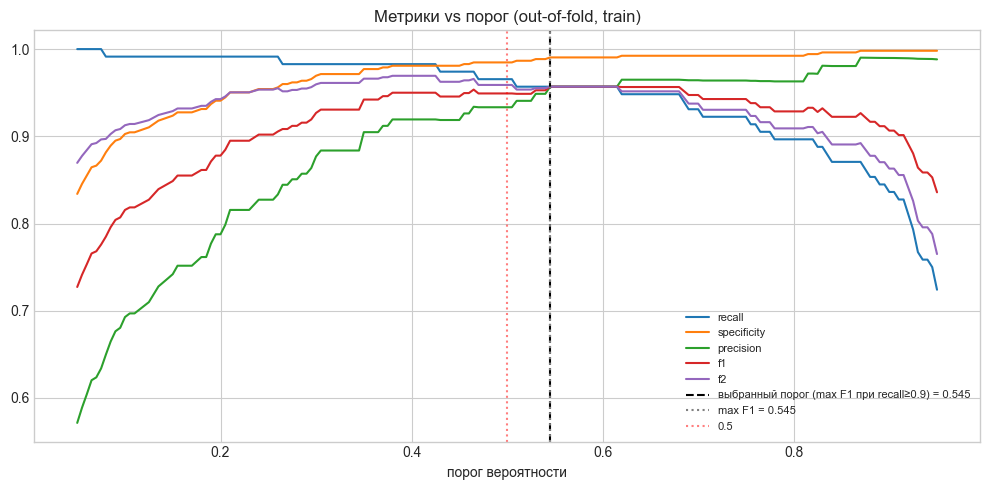

,recall,specificity,precision,f1,f2
threshold,,,,,
0.300,0.983,0.969,0.877,0.927,0.960
0.545,0.957,0.990,0.957,0.957,0.957
0.545,0.957,0.990,0.957,0.957,0.957
0.500,0.966,0.985,0.933,0.949,0.959
0.700,0.931,0.992,0.964,0.947,0.938


In [10]:
oof = cross_val_predict(best_pipe, X_tr, y_tr, cv=cv5, method='predict_proba', n_jobs=-1)[:, 1]
thr_grid = np.linspace(0.05, 0.95, 181)


def metrics_at(y_true, proba, t):
    p = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, p, labels=[0, 1]).ravel()
    rec = tp / (tp + fn) if tp + fn else 0
    prec = tp / (tp + fp) if tp + fp else 0
    spec = tn / (tn + fp) if tn + fp else 0
    f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0
    f2 = 5 * prec * rec / (4 * prec + rec) if prec + rec else 0
    return dict(threshold=t, recall=rec, specificity=spec, precision=prec, f1=f1, f2=f2)


thr_df = pd.DataFrame([metrics_at(y_tr, oof, t) for t in thr_grid])
MIN_RECALL = 0.90
ok = thr_df[thr_df['recall'] >= MIN_RECALL]
THRESHOLD = float(ok.loc[ok['f1'].idxmax(), 'threshold'])
thr_f1 = float(thr_df.loc[thr_df['f1'].idxmax(), 'threshold'])

fig, ax = plt.subplots(figsize=(10, 5))
for col in ['recall', 'specificity', 'precision', 'f1', 'f2']:
    ax.plot(thr_df['threshold'], thr_df[col], label=col)
ax.axvline(THRESHOLD, color='k', ls='--', label=f'выбранный порог (max F1 при recall≥{MIN_RECALL}) = {THRESHOLD:.3f}')
ax.axvline(thr_f1, color='grey', ls=':', label=f'max F1 = {thr_f1:.3f}')
ax.axvline(0.5, color='red', ls=':', alpha=0.5, label='0.5')
ax.set_xlabel('порог вероятности'); ax.set_title('Метрики vs порог (out-of-fold, train)'); ax.legend(fontsize=8)
plt.tight_layout(); save(fig, '06_threshold.png'); plt.show()
display(thr_df.set_index('threshold').loc[[thr_df['threshold'].iloc[(thr_df['threshold'] - t).abs().argmin()]
                                           for t in [0.3, THRESHOLD, thr_f1, 0.5, 0.7]]])

### Финальная оценка на отложенной выборке (holdout, 160 пациентов)

In [11]:
proba_ho = best_pipe.predict_proba(X_ho)[:, 1]


def report(y_true, proba, t):
    p = (proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, p).ravel()
    return {
        'Accuracy': accuracy_score(y_true, p),
        'Recall (Sensitivity)': recall_score(y_true, p),
        'Specificity': tn / (tn + fp),
        'Precision (PPV)': precision_score(y_true, p, zero_division=0),
        'NPV': tn / (tn + fn),
        'F1': f1_score(y_true, p),
        'ROC-AUC': roc_auc_score(y_true, proba),
        'Brier': brier_score_loss(y_true, proba),
        'TP/FN/FP/TN': f'{tp}/{fn}/{fp}/{tn}',
    }


# Для сравнения — базовая SVM из vanilla-ноутбука (8 признаков), но честно: без утечки, в пайплайне
BASE_FEATS = ['ИМТ', 'Окружность_талии_см', 'САД_мм_рт_ст', 'ДАД_мм_рт_ст',
              'ЛПНП_ммоль_л', 'ЛПВП_ммоль_л', 'Триглицериды_ммоль_л', 'Курение']
from sklearn.impute import SimpleImputer
baseline = Pipeline([('imp', SimpleImputer(strategy='mean')), ('sc', StandardScaler()),
                     ('clf', SVC(kernel='rbf', C=1.0, class_weight='balanced', probability=True,
                                 random_state=RANDOM_STATE))]).fit(X_tr[BASE_FEATS], y_tr)
base_proba = baseline.predict_proba(X_ho[BASE_FEATS])[:, 1]
base_pred_default = baseline.predict(X_ho[BASE_FEATS])  # predict() SVC = решающая функция, не proba>=0.5

holdout = pd.DataFrame({
    'Базовая SVM (8 признаков, predict)': {**report(y_ho, base_proba, 0.5),
                                           **{k: v for k, v in report(y_ho, base_pred_default.astype(float), 0.5).items()
                                              if k not in ('ROC-AUC', 'Brier')}},
    f'{best_name}, порог 0.5': report(y_ho, proba_ho, 0.5),
    f'{best_name}, порог {THRESHOLD:.3f} (recall≥0.9)': report(y_ho, proba_ho, THRESHOLD),
}).T
display(holdout)
print(classification_report(y_ho, (proba_ho >= THRESHOLD).astype(int), target_names=['низкий', 'высокий']))

,Accuracy,Recall (Sensitivity),Specificity,Precision (PPV),NPV,F1,ROC-AUC,Brier,TP/FN/FP/TN
"Базовая SVM (8 признаков, predict)",0.875,0.828,0.885,0.615,0.959,0.706,0.907,0.080,24/5/15/116
"HistGradientBoosting, порог 0.5",1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.005,29/0/0/131
"HistGradientBoosting, порог 0.545 (recall≥0.9)",1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.005,29/0/0/131


              precision    recall  f1-score   support

      низкий       1.00      1.00      1.00       131
     высокий       1.00      1.00      1.00        29

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160



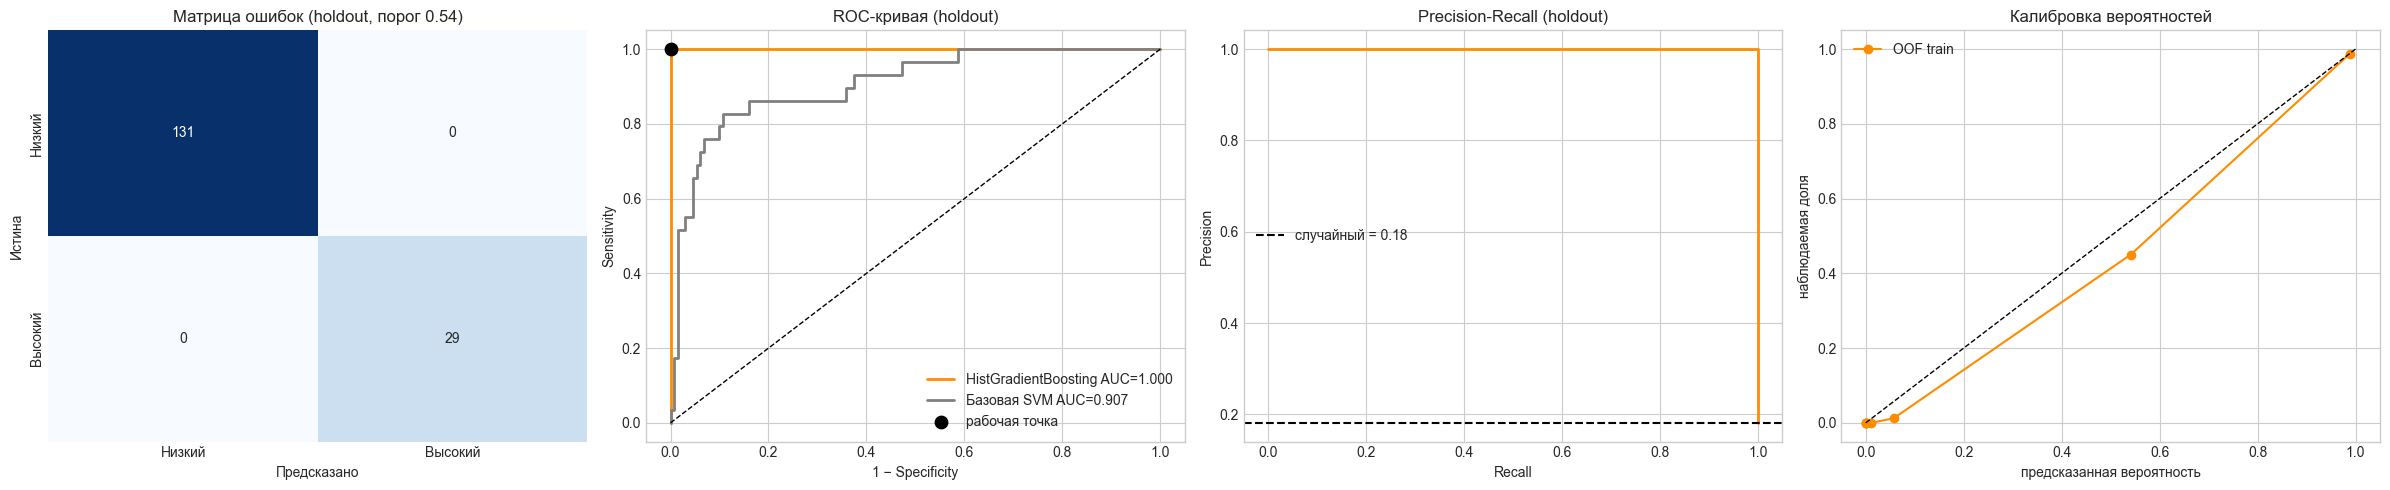

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
pred_ho = (proba_ho >= THRESHOLD).astype(int)
cm = confusion_matrix(y_ho, pred_ho)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Низкий', 'Высокий'], yticklabels=['Низкий', 'Высокий'])
axes[0].set_xlabel('Предсказано'); axes[0].set_ylabel('Истина')
axes[0].set_title(f'Матрица ошибок (holdout, порог {THRESHOLD:.2f})')

for proba, lab, c in [(proba_ho, best_name, 'darkorange'), (base_proba, 'Базовая SVM', 'grey')]:
    fpr, tpr, _ = roc_curve(y_ho, proba)
    axes[1].plot(fpr, tpr, lw=2, color=c, label=f'{lab} AUC={roc_auc_score(y_ho, proba):.3f}')
t_idx = np.argmin(np.abs(roc_curve(y_ho, proba_ho)[2] - THRESHOLD))
fpr, tpr, thr = roc_curve(y_ho, proba_ho)
axes[1].scatter(1 - report(y_ho, proba_ho, THRESHOLD)['Specificity'],
                report(y_ho, proba_ho, THRESHOLD)['Recall (Sensitivity)'], s=80, c='k', zorder=5,
                label='рабочая точка')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('1 − Specificity'); axes[1].set_ylabel('Sensitivity'); axes[1].set_title('ROC-кривая (holdout)')
axes[1].legend(loc='lower right')

prec, rec, _ = precision_recall_curve(y_ho, proba_ho)
axes[2].plot(rec, prec, color='darkorange', lw=2)
axes[2].axhline(y_ho.mean(), color='k', ls='--', label=f'случайный = {y_ho.mean():.2f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision'); axes[2].set_title('Precision-Recall (holdout)')
axes[2].legend()

frac_pos, mean_pred = calibration_curve(y_tr, oof, n_bins=8, strategy='quantile')
axes[3].plot(mean_pred, frac_pos, 'o-', color='darkorange', label='OOF train')
axes[3].plot([0, 1], [0, 1], 'k--', lw=1)
axes[3].set_xlabel('предсказанная вероятность'); axes[3].set_ylabel('наблюдаемая доля')
axes[3].set_title('Калибровка вероятностей'); axes[3].legend()
plt.tight_layout(); save(fig, '07_holdout_eval.png'); plt.show()

### Важность признаков

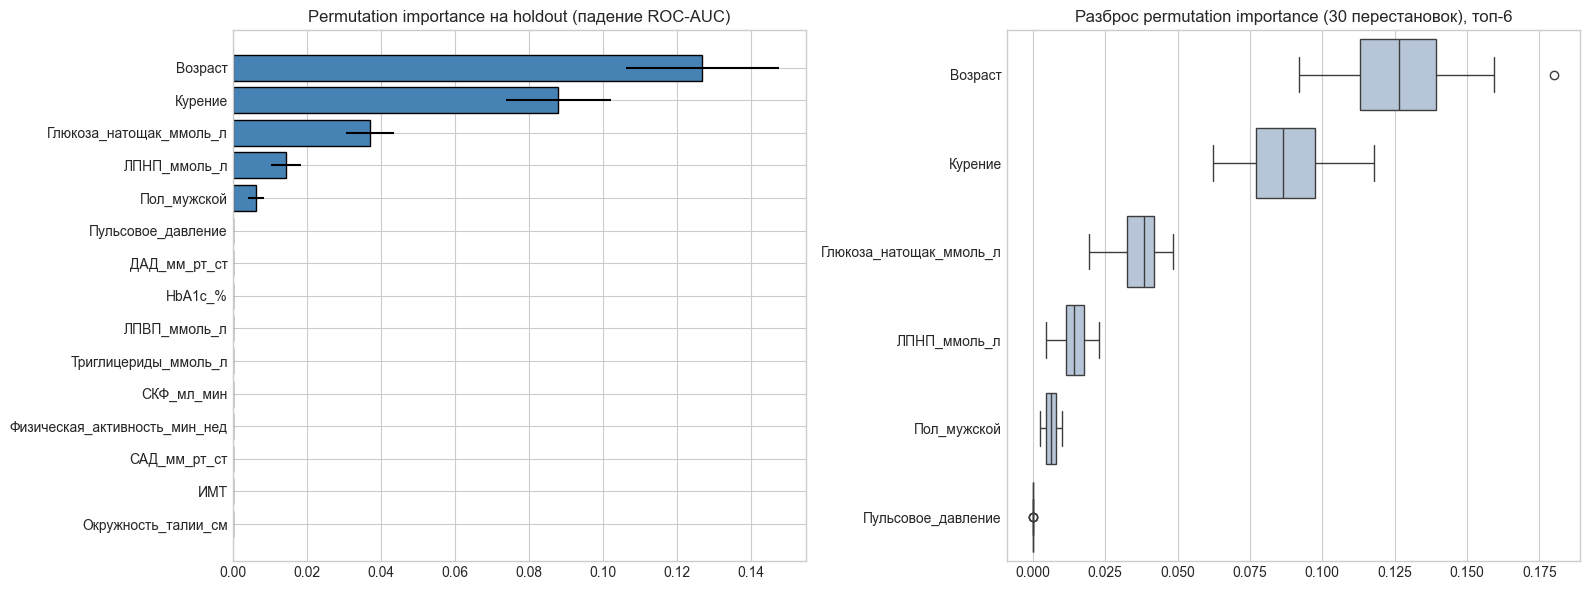

Дерево-суррогат глубины 3 воспроизводит решения модели на train с точностью 94.2%:
|--- Возраст <= 58.50
|   |--- ЛПНП_ммоль_л <= 3.99
|   |   |--- САД_мм_рт_ст <= 139.61
|   |   |   |--- class: 0
|   |   |--- САД_мм_рт_ст >  139.61
|   |   |   |--- class: 1
|   |--- ЛПНП_ммоль_л >  3.99
|   |   |--- Пульсовое_давление <= 44.67
|   |   |   |--- class: 1
|   |   |--- Пульсовое_давление >  44.67
|   |   |   |--- class: 0
|--- Возраст >  58.50
|   |--- Курение <= 0.50
|   |   |--- ЛПНП_ммоль_л <= 4.04
|   |   |   |--- class: 0
|   |   |--- ЛПНП_ммоль_л >  4.04
|   |   |   |--- class: 1
|   |--- Курение >  0.50
|   |   |--- class: 1



In [13]:
perm = permutation_importance(best_pipe, X_ho, y_ho, scoring='roc_auc', n_repeats=30,
                              random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values()
imp_std = pd.Series(perm.importances_std, index=FEATURES)[imp.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(imp.index, imp.values, xerr=imp_std.values, color='steelblue', edgecolor='black')
axes[0].set_title('Permutation importance на holdout (падение ROC-AUC)')

clf = best_pipe.named_steps['clf']
if hasattr(clf, 'coef_'):
    names = best_pipe.named_steps['imp'].get_feature_names_out(FEATURES)
    coef = pd.Series(clf.coef_.ravel(), index=names).sort_values()
    axes[1].barh(coef.index, coef.values, color=np.where(coef.values > 0, '#d62828', '#2a9d8f'))
    axes[1].set_title('Стандартизованные коэффициенты (>0 — повышают риск)')
    display(pd.DataFrame({'coef': coef, 'odds ratio на 1 SD': np.exp(coef)}).sort_values('coef', ascending=False))
else:
    grp = pd.DataFrame(perm.importances.T, columns=FEATURES)[imp.index[::-1][:6]]
    sns.boxplot(data=grp, orient='h', ax=axes[1], color='lightsteelblue')
    axes[1].set_title('Разброс permutation importance (30 перестановок), топ-6')
plt.tight_layout(); save(fig, '08_feature_importance.png'); plt.show()

# Интерпретация «чёрного ящика»: неглубокое дерево-суррогат, обученное повторять решения модели на train
from sklearn.tree import DecisionTreeClassifier, export_text
X_tr_imp = pd.DataFrame(IterativeImputer(random_state=RANDOM_STATE, max_iter=20).fit_transform(X_tr), columns=FEATURES)
model_dec = (best_pipe.predict_proba(X_tr)[:, 1] >= THRESHOLD).astype(int)
surrogate = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE).fit(X_tr_imp, model_dec)
print(f'Дерево-суррогат глубины 3 воспроизводит решения модели на train с точностью '
      f'{surrogate.score(X_tr_imp, model_dec):.1%}:')
print(export_text(surrogate, feature_names=FEATURES, decimals=2))

### Анализ ошибок: кого модель пропускает?

In [14]:
err = X_ho.copy()
err['y'] = y_ho; err['proba'] = proba_ho; err['pred'] = pred_ho
err['тип'] = np.select([(err.y == 1) & (err.pred == 1), (err.y == 0) & (err.pred == 0),
                        (err.y == 1) & (err.pred == 0)], ['TP', 'TN', 'FN'], 'FP')
display(err.groupby('тип')[['Возраст', 'САД_мм_рт_ст', 'ЛПНП_ммоль_л', 'ЛПВП_ммоль_л', 'Курение',
                             'Глюкоза_натощак_ммоль_л', 'proba']].mean())
print('Ложноотрицательные (пропущенные высокорисковые) пациенты:')
display(err[err['тип'] == 'FN'][FEATURES + ['proba']])

,Возраст,САД_мм_рт_ст,ЛПНП_ммоль_л,ЛПВП_ммоль_л,Курение,Глюкоза_натощак_ммоль_л,proba
тип,,,,,,,
TN,50.702,112.396,2.869,1.595,0.191,4.983,0.026
TP,60.207,123.134,3.443,1.297,0.724,5.606,0.969


Ложноотрицательные (пропущенные высокорисковые) пациенты:


,Возраст,Пол_мужской,ИМТ,Окружность_талии_см,САД_мм_рт_ст,ДАД_мм_рт_ст,Пульсовое_давление,Глюкоза_натощак_ммоль_л,HbA1c_%,ЛПНП_ммоль_л,ЛПВП_ммоль_л,Триглицериды_ммоль_л,СКФ_мл_мин,Курение,Физическая_активность_мин_нед,proba


### Обучение на всех 800 пациентах и прогноз для test

In [15]:
final_model = make_pipe(best_pipe.named_steps['clf']).set_params(
    **{k: v for k, v in searches[best_name].best_params_.items()})
final_model.fit(X, y)

test_proba = final_model.predict_proba(test_features[FEATURES])[:, 1]
test_pred = (test_proba >= THRESHOLD).astype(int)

submission = pd.DataFrame({'patient_id': test_features[ID].values, 'prediction': test_pred})
assert len(submission) == len(test_features)
assert submission['patient_id'].tolist() == test_features[ID].tolist()
assert submission.notna().all().all() and set(submission['prediction']) <= {0, 1}

out_path = repo_root / 'outputs' / 'task1_predictions.csv'
submission.to_csv(out_path, index=False)
print(f'Сохранено: {out_path}  ({len(submission)} строк)')
print(f'Доля прогнозов «высокий риск» в test: {test_pred.mean():.1%}  (в train истинная доля {y.mean():.1%})')

# Дополнительно: вероятности — полезны клиницисту больше, чем бинарная метка
pd.DataFrame({'patient_id': test_features[ID], 'cvd_risk_probability': test_proba.round(4),
              'prediction': test_pred}).to_csv(repo_root / 'outputs' / 'task1_test_probabilities.csv', index=False)

Сохранено: C:\Users\Dima\AppData\Local\Temp\claude\C--Games-ebprilozhenie\5ebca703-1b24-4c4f-8e86-2de2aed1c817\scratchpad\repo\outputs\task1_predictions.csv  (200 строк)
Доля прогнозов «высокий риск» в test: 19.0%  (в train истинная доля 18.1%)


## 4. Нечёткий KNN для пограничной глюкозы (5.4–6.5 ммоль/л)

Улучшения относительно базовой версии:
- **Настоящий Fuzzy KNN (Keller, Gray, Givens, 1985):** у каждого обучающего пациента не жёсткая метка, а начальная степень принадлежности, рассчитанная по его собственным `k_init` соседям: `u_c = 0.51 + 0.49·n_c/k` для своего класса и `0.49·n_c/k` для остальных. Итоговая принадлежность — взвешенное по `1/d^(2/(m−1))` среднее принадлежностей соседей.
- Импутер и масштабатор **обучаются только на обучающей части** пограничной группы (в базовой версии — на всей группе до разбиения).
- **Вес глюкозы.** EDA пограничной группы (ниже) показывает, что `Статус_глюкозы` в этих симулированных данных задан порогами одной глюкозы натощак (≤5.6 — норма, 5.6–6.1 — преддиабет, >6.1 — диабет). При равных весах KNN «размывает» глюкозу остальными признаками, поэтому после стандартизации столбец глюкозы умножается на вес `w_glu`, подобранный CV. ИМТ, талия, ТГ, ЛПВП, HbA1c и возраст остаются как метаболический контекст.
- `k`, `m`, `k_init`, `w_glu` подбираются кросс-валидацией по log-loss (качество вероятностей), а не фиксируются.
- Принадлежности сглаживаются (ε = 1e-3), чтобы не было нулевых вероятностей и log-loss был конечным.
- Метрики: accuracy, macro-F1, log-loss, Brier; неопределённость — энтропия принадлежностей и разрыв между двумя наибольшими принадлежностями.
- Применение к пограничным пациентам **test** — только по признакам, тестовые метки не используются.

Пограничная группа: train 247 (31%), test 66


,count,min,max
Статус_глюкозы,,,
Норма,69,5.404,5.590
Преддиабет,120,5.601,6.096
Диабет,58,6.113,6.495


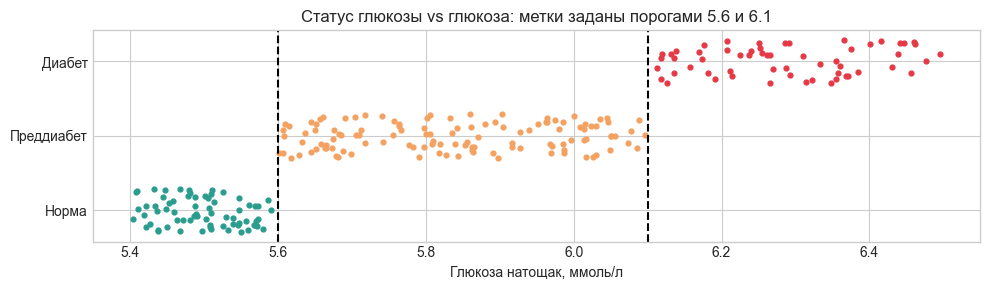

Лучшие параметры Fuzzy KNN: {'fknn__k': 5, 'fknn__k_init': 3, 'fknn__m': 1.5, 'w__weight': 10} | CV log-loss=0.080 | CV macro-F1=0.977


In [16]:
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin
from sklearn.neighbors import NearestNeighbors


class FuzzyKNN(ClassifierMixin, BaseEstimator):
    # Нечёткий KNN Keller et al. (1985) с нечёткой инициализацией меток

    def __init__(self, k=7, m=2.0, k_init=5):
        self.k, self.m, self.k_init = k, m, k_init

    def fit(self, X, y):
        X = np.asarray(X, float); y = np.asarray(y).astype(int)
        self.classes_ = np.unique(y)
        idx = np.searchsorted(self.classes_, y)
        nn = NearestNeighbors(n_neighbors=self.k_init + 1).fit(X)
        neigh = nn.kneighbors(X, return_distance=False)[:, 1:]  # без самого себя
        counts = np.stack([(idx[neigh] == c).sum(1) for c in range(len(self.classes_))], 1)
        U = 0.49 * counts / self.k_init
        U[np.arange(len(y)), idx] += 0.51
        self.U_ = U
        self.X_ = X
        self.nn_ = NearestNeighbors(n_neighbors=self.k).fit(X)
        return self

    def predict_proba(self, X):
        d, ind = self.nn_.kneighbors(np.asarray(X, float))
        w = 1.0 / np.maximum(d, 1e-9) ** (2.0 / (self.m - 1.0))
        mem = np.einsum('nk,nkc->nc', w, self.U_[ind])
        mem = mem / mem.sum(1, keepdims=True) + 1e-3  # сглаживание: без нулевых принадлежностей
        return mem / mem.sum(1, keepdims=True)

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(1)]


class ColumnWeight(TransformerMixin, BaseEstimator):
    # Умножает один столбец (после стандартизации) на вес — простое метрическое обучение для KNN

    def __init__(self, col=0, weight=1.0):
        self.col, self.weight = col, weight

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.array(X, float)
        X[:, self.col] *= self.weight
        return X


FUZZY_FEATURES = ['Глюкоза_натощак_ммоль_л', 'HbA1c_%', 'ИМТ', 'Окружность_талии_см',
                  'Триглицериды_ммоль_л', 'ЛПВП_ммоль_л', 'Возраст']
CLASS_NAMES = ['Норма', 'Преддиабет', 'Диабет']
RISK_WEIGHTS = np.array([0.0, 0.5, 1.0])

border = df[df['Глюкоза_натощак_ммоль_л'].between(5.4, 6.5)].copy()
border_test = test_features[test_features['Глюкоза_натощак_ммоль_л'].between(5.4, 6.5)].copy()
print(f'Пограничная группа: train {len(border)} ({len(border) / len(df):.0%}), test {len(border_test)}')
display(border.groupby('Статус_глюкозы')['Глюкоза_натощак_ммоль_л'].agg(['count', 'min', 'max'])
        .rename(index=dict(enumerate(CLASS_NAMES))))

fig, ax = plt.subplots(figsize=(10, 3))
for c, col in enumerate(['#2a9d8f', '#f4a261', '#e63946']):
    g = border.loc[border['Статус_глюкозы'] == c, 'Глюкоза_натощак_ммоль_л']
    ax.scatter(g, np.random.uniform(-0.3, 0.3, len(g)) + c, s=12, color=col, label=CLASS_NAMES[c])
ax.axvline(5.6, ls='--', c='k'); ax.axvline(6.1, ls='--', c='k')
ax.set_yticks(range(3)); ax.set_yticklabels(CLASS_NAMES); ax.set_xlabel('Глюкоза натощак, ммоль/л')
ax.set_title('Статус глюкозы vs глюкоза: метки заданы порогами 5.6 и 6.1')
plt.tight_layout(); save(fig, '09a_glucose_status_rule.png'); plt.show()

Xb, yb = border[FUZZY_FEATURES], border['Статус_глюкозы'].values
Xb_tr, Xb_ho, yb_tr, yb_ho = train_test_split(Xb, yb, test_size=0.3, stratify=yb, random_state=RANDOM_STATE)


def fuzzy_pipe(**kw):
    return Pipeline([('imp', IterativeImputer(random_state=RANDOM_STATE, max_iter=20)),
                     ('sc', StandardScaler()), ('w', ColumnWeight(col=0)), ('fknn', FuzzyKNN(**kw))])


fgs = GridSearchCV(fuzzy_pipe(), {'fknn__k': [5, 9, 15, 25], 'fknn__m': [1.5, 2.0, 3.0],
                                  'fknn__k_init': [3, 7], 'w__weight': [1, 3, 6, 10]},
                   scoring={'neg_log_loss': 'neg_log_loss', 'f1_macro': 'f1_macro'}, refit='neg_log_loss',
                   cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE), n_jobs=-1)
fgs.fit(Xb_tr, yb_tr)
fuzzy = fgs.best_estimator_
print('Лучшие параметры Fuzzy KNN:', fgs.best_params_,
      f'| CV log-loss={-fgs.best_score_:.3f}',
      f'| CV macro-F1={fgs.cv_results_["mean_test_f1_macro"][fgs.best_index_]:.3f}')

In [17]:
from sklearn.neighbors import KNeighborsClassifier


def entropy(P):
    return -(P * np.log(np.clip(P, 1e-12, 1))).sum(1) / np.log(P.shape[1])


mem_ho = fuzzy.predict_proba(Xb_ho)
hard_knn = Pipeline([('imp', IterativeImputer(random_state=RANDOM_STATE, max_iter=20)), ('sc', StandardScaler()),
                     ('w', ColumnWeight(col=0, weight=fgs.best_params_['w__weight'])),
                     ('knn', KNeighborsClassifier(n_neighbors=fgs.best_params_['fknn__k']))]).fit(Xb_tr, yb_tr)
knn_proba = hard_knn.predict_proba(Xb_ho)

fz_metrics = pd.DataFrame({
    'Fuzzy KNN': {'Accuracy': accuracy_score(yb_ho, mem_ho.argmax(1)),
                  'macro-F1': f1_score(yb_ho, mem_ho.argmax(1), average='macro'),
                  'log-loss': log_loss(yb_ho, mem_ho, labels=[0, 1, 2]),
                  'Brier (multi)': np.mean(np.sum((mem_ho - np.eye(3)[yb_ho]) ** 2, 1))},
    'Обычный KNN (жёсткий)': {'Accuracy': accuracy_score(yb_ho, knn_proba.argmax(1)),
                              'macro-F1': f1_score(yb_ho, knn_proba.argmax(1), average='macro'),
                              'log-loss': log_loss(yb_ho, np.clip(knn_proba, 1e-3, 1), labels=[0, 1, 2]),
                              'Brier (multi)': np.mean(np.sum((knn_proba - np.eye(3)[yb_ho]) ** 2, 1))},
}).T
display(fz_metrics)
print(classification_report(yb_ho, mem_ho.argmax(1), target_names=CLASS_NAMES))

risk_ho = mem_ho @ RISK_WEIGHTS
H_ho = entropy(mem_ho)
top2 = np.sort(mem_ho, 1)
margin_ho = top2[:, -1] - top2[:, -2]
UNCERTAIN = margin_ho < 0.3
correct = mem_ho.argmax(1) == yb_ho
glu = Xb_ho['Глюкоза_натощак_ммоль_л'].values
near_cut = np.minimum(np.abs(glu - 5.6), np.abs(glu - 6.1))
print(f'Среднее расстояние глюкозы до ближайшего порога: неопределённые {near_cut[UNCERTAIN].mean():.2f}, '
      f'уверенные {near_cut[~UNCERTAIN].mean():.2f} ммоль/л')
print(f'Неопределённых случаев (разрыв top-2 < 0.3): {UNCERTAIN.sum()} из {len(yb_ho)}; '
      f'точность среди них {correct[UNCERTAIN].mean():.0%}, среди уверенных {correct[~UNCERTAIN].mean():.0%}')

,Accuracy,macro-F1,log-loss,Brier (multi)
Fuzzy KNN,0.973,0.975,0.054,0.032
Обычный KNN (жёсткий),0.987,0.988,0.054,0.034


              precision    recall  f1-score   support

       Норма       0.91      1.00      0.95        21
  Преддиабет       1.00      0.94      0.97        36
      Диабет       1.00      1.00      1.00        18

    accuracy                           0.97        75
   macro avg       0.97      0.98      0.98        75
weighted avg       0.98      0.97      0.97        75

Среднее расстояние глюкозы до ближайшего порога: неопределённые 0.02, уверенные 0.15 ммоль/л
Неопределённых случаев (разрыв top-2 < 0.3): 1 из 75; точность среди них 0%, среди уверенных 99%


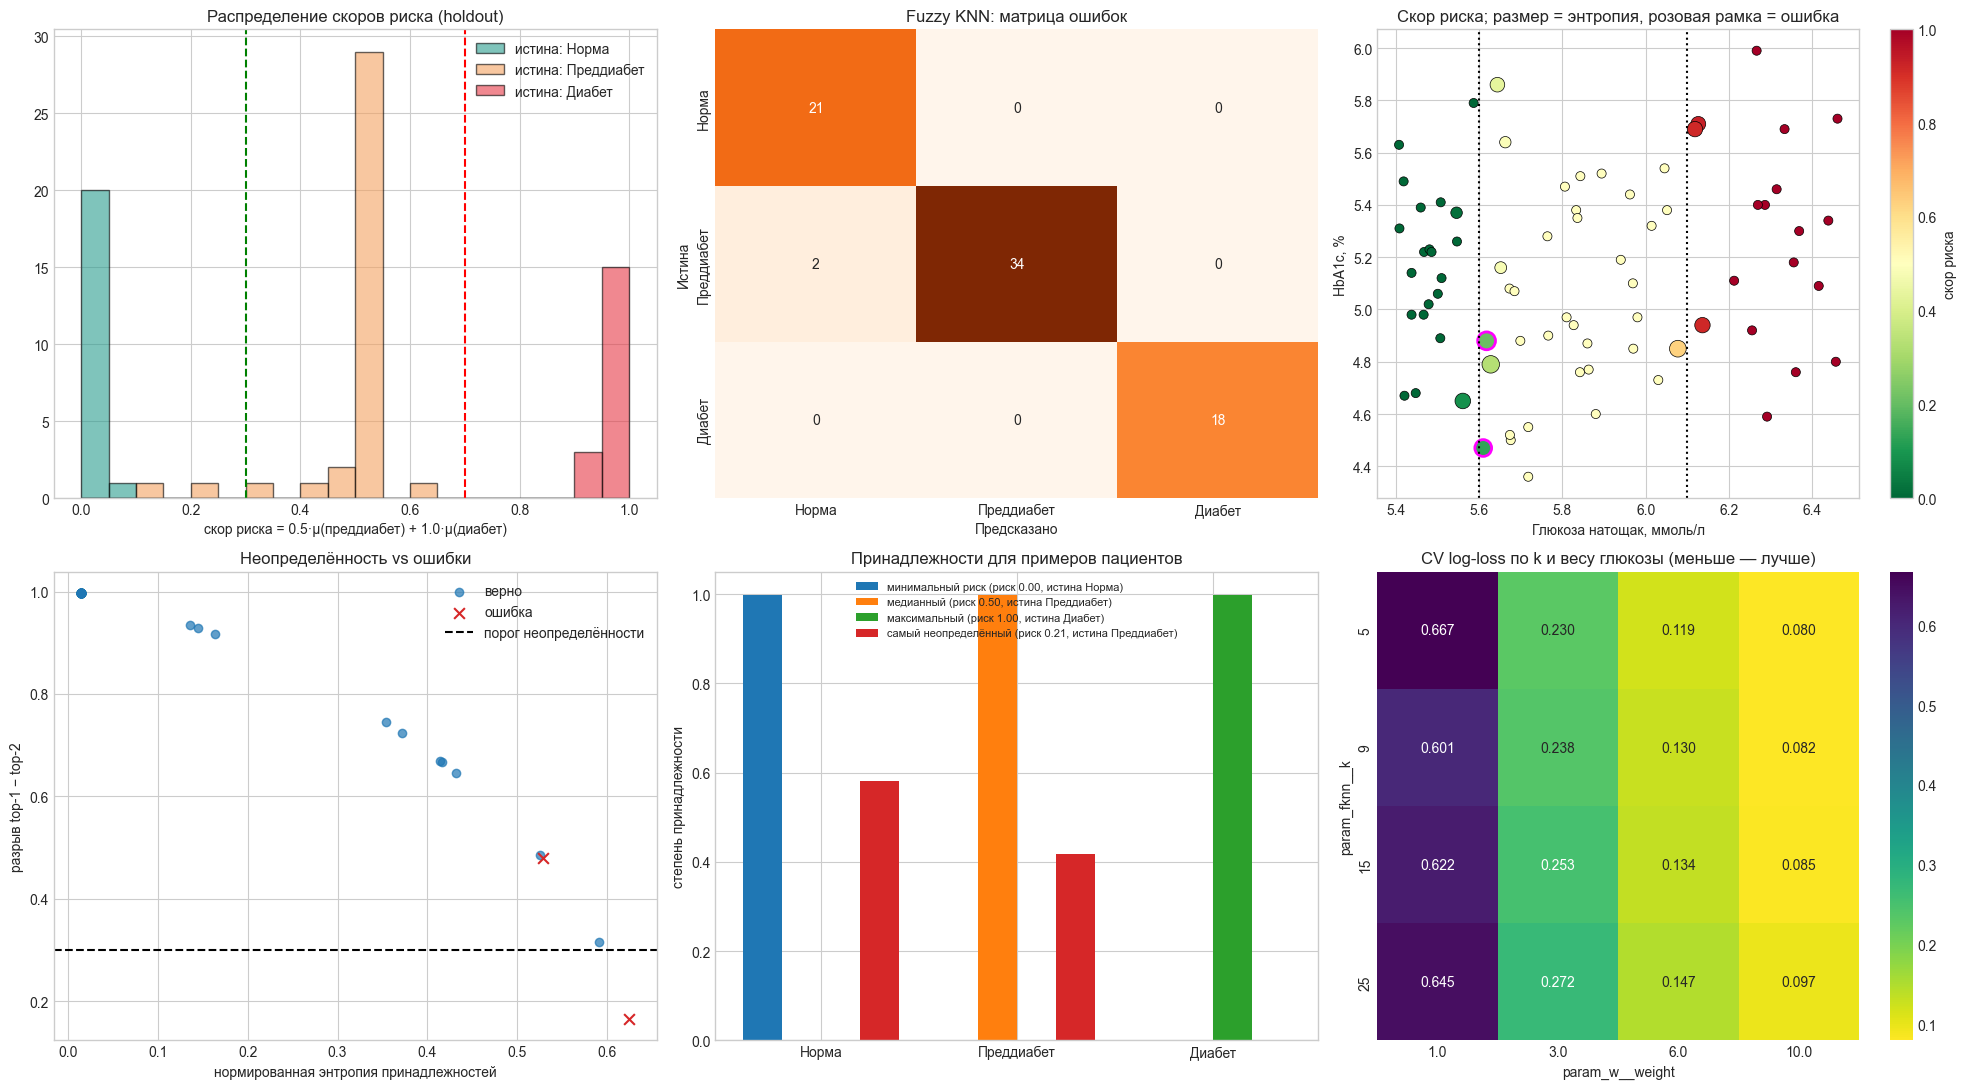

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

ax = axes[0, 0]
for c, col in enumerate(['#2a9d8f', '#f4a261', '#e63946']):
    ax.hist(risk_ho[yb_ho == c], bins=np.linspace(0, 1, 21), alpha=0.6, color=col, label=f'истина: {CLASS_NAMES[c]}',
            edgecolor='black')
ax.axvline(0.3, ls='--', color='green'); ax.axvline(0.7, ls='--', color='red')
ax.set_xlabel('скор риска = 0.5·μ(преддиабет) + 1.0·μ(диабет)'); ax.set_title('Распределение скоров риска (holdout)')
ax.legend()

ax = axes[0, 1]
cm_f = confusion_matrix(yb_ho, mem_ho.argmax(1))
sns.heatmap(cm_f, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=ax, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_xlabel('Предсказано'); ax.set_ylabel('Истина'); ax.set_title('Fuzzy KNN: матрица ошибок')

ax = axes[0, 2]
sc = ax.scatter(Xb_ho['Глюкоза_натощак_ммоль_л'], Xb_ho['HbA1c_%'], c=risk_ho, cmap='RdYlGn_r', s=40 + 200 * H_ho,
                edgecolors=np.where(correct, 'k', 'magenta'), linewidths=np.where(correct, 0.5, 2), vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label='скор риска')
ax.axvline(5.6, ls=':', color='k'); ax.axvline(6.1, ls=':', color='k')
ax.set_xlabel('Глюкоза натощак, ммоль/л'); ax.set_ylabel('HbA1c, %')
ax.set_title('Скор риска; размер = энтропия, розовая рамка = ошибка')

ax = axes[1, 0]
ax.scatter(H_ho[correct], margin_ho[correct], c='tab:blue', label='верно', alpha=0.7)
ax.scatter(H_ho[~correct], margin_ho[~correct], c='tab:red', marker='x', s=60, label='ошибка')
ax.axhline(0.3, ls='--', color='k', label='порог неопределённости')
ax.set_xlabel('нормированная энтропия принадлежностей'); ax.set_ylabel('разрыв top-1 − top-2')
ax.set_title('Неопределённость vs ошибки'); ax.legend()

ax = axes[1, 1]
order = np.argsort(risk_ho)
examples = [order[0], order[len(order) // 2], order[-1], int(np.argmax(H_ho))]
titles = ['минимальный риск', 'медианный', 'максимальный', 'самый неопределённый']
w = 0.2
for j, (i, t) in enumerate(zip(examples, titles)):
    ax.bar(np.arange(3) + (j - 1.5) * w, mem_ho[i], w, label=f'{t} (риск {risk_ho[i]:.2f}, истина {CLASS_NAMES[yb_ho[i]]})')
ax.set_xticks(range(3)); ax.set_xticklabels(CLASS_NAMES); ax.set_ylim(0, 1.05)
ax.set_ylabel('степень принадлежности'); ax.set_title('Принадлежности для примеров пациентов'); ax.legend(fontsize=8)

ax = axes[1, 2]
res = pd.DataFrame(fgs.cv_results_)
sel = ((res['param_fknn__k_init'].astype(int) == fgs.best_params_['fknn__k_init'])
       & (res['param_fknn__m'].astype(float) == fgs.best_params_['fknn__m']))
piv = res[sel].astype({'param_fknn__k': int, 'param_w__weight': float}).pivot_table(
    index='param_fknn__k', columns='param_w__weight', values='mean_test_neg_log_loss')
sns.heatmap(-piv, annot=True, fmt='.3f', cmap='viridis_r', ax=ax)
ax.set_title('CV log-loss по k и весу глюкозы (меньше — лучше)')
plt.tight_layout(); save(fig, '09_fuzzy_knn.png'); plt.show()

In [19]:
# Переобучаем Fuzzy KNN на всей пограничной группе train и применяем к пограничным пациентам test
fuzzy_final = fuzzy_pipe().set_params(**fgs.best_params_).fit(Xb, yb)
mem_t = fuzzy_final.predict_proba(border_test[FUZZY_FEATURES])
s = np.sort(mem_t, 1)
fuzzy_out = pd.DataFrame({
    'patient_id': border_test[ID].values,
    'μ_норма': mem_t[:, 0], 'μ_преддиабет': mem_t[:, 1], 'μ_диабет': mem_t[:, 2],
    'скор_риска': mem_t @ RISK_WEIGHTS,
    'энтропия': entropy(mem_t),
    'неопределённый_случай': (s[:, -1] - s[:, -2]) < 0.3,
}).round(4)
fuzzy_out['группа'] = pd.cut(fuzzy_out['скор_риска'], [-0.01, 0.3, 0.7, 1.01], labels=['низкий', 'умеренный', 'высокий'])
fuzzy_out.to_csv(repo_root / 'outputs' / 'task1_fuzzy_knn_borderline_test.csv', index=False)
print(f'{len(fuzzy_out)} пограничных пациентов test, из них неопределённых: {fuzzy_out["неопределённый_случай"].sum()}')
display(fuzzy_out['группа'].value_counts().to_frame())
display(fuzzy_out.sort_values('энтропия', ascending=False).head(10))

66 пограничных пациентов test, из них неопределённых: 3


,count
группа,
умеренный,30
низкий,26
высокий,10


,patient_id,μ_норма,μ_преддиабет,μ_диабет,скор_риска,энтропия,неопределённый_случай,группа
27,460,0.565,0.434,0.001,0.218,0.630,True,низкий
30,491,0.001,0.373,0.626,0.812,0.608,True,высокий
49,804,0.368,0.631,0.001,0.317,0.606,True,умеренный
41,679,0.001,0.746,0.253,0.626,0.521,False,умеренный
31,499,0.756,0.243,0.001,0.123,0.512,False,низкий
36,591,0.218,0.781,0.001,0.391,0.485,False,умеренный
2,63,0.794,0.205,0.001,0.103,0.469,False,низкий
12,217,0.001,0.166,0.833,0.916,0.416,False,высокий
29,470,0.838,0.161,0.001,0.081,0.408,False,низкий
55,872,0.143,0.856,0.001,0.429,0.381,False,умеренный


## 5. Сводка

In [20]:
summary = holdout.loc[[f'{best_name}, порог {THRESHOLD:.3f} (recall≥0.9)', 'Базовая SVM (8 признаков, predict)'],
                      ['Accuracy', 'Recall (Sensitivity)', 'Specificity', 'Precision (PPV)', 'F1', 'ROC-AUC']]
display(summary)
display(fz_metrics)

,Accuracy,Recall (Sensitivity),Specificity,Precision (PPV),F1,ROC-AUC
"HistGradientBoosting, порог 0.545 (recall≥0.9)",1.000,1.000,1.000,1.000,1.000,1.000
"Базовая SVM (8 признаков, predict)",0.875,0.828,0.885,0.615,0.706,0.907


,Accuracy,macro-F1,log-loss,Brier (multi)
Fuzzy KNN,0.973,0.975,0.054,0.032
Обычный KNN (жёсткий),0.987,0.988,0.054,0.034


## 6. Отчёт (≤ 2000 знаков)

**Предобработка.** Из признаков исключены `patient_id` и все целевые столбцы (`prediction`, `Статус_глюкозы`, `Доклинический_риск`). Пропуски ЛПНП/ЛПВП/ТГ/СКФ (4–6%) заполняет `IterativeImputer` с индикаторами пропуска, затем `StandardScaler`. Всё внутри `Pipeline` и обучается только на train-фолдах. В базовом ноутбуке scaler обучался до разбиения (утечка), а возраст не использовался.

**Модель и дисбаланс (18% положительных).** Сравнил LogReg, SVM, RF и HistGradientBoosting (5-fold×3 CV, `class_weight='balanced'`), затем `GridSearchCV`. Лучший — бустинг (CV ROC-AUC 0.998 против 0.970 у SVM). Порог 0.545 — максимум F1 при recall ≥ 0.9 на out-of-fold вероятностях train (OOF: recall 0.96, specificity 0.99, F1 0.96).

**Качество на holdout (160).** Бустинг: Accuracy/Recall/Specificity/F1/ROC-AUC = 1.00. Базовая SVM: 0.875/0.83/0.89/0.71/0.91. Идеальный результат объясняется симуляцией: метка — почти детерминированное правило от признаков, что показывает дерево-суррогат глубины 3. На реальных данных так не будет.

**Важные признаки.** Возраст, курение, глюкоза, ЛПНП, пол (permutation importance). Суррогат: возраст > 58.5 и курение, ЛПНП > 4, САД > 140. Это согласуется с клиническими шкалами (SCORE2).

**Fuzzy KNN (глюкоза 5.4–6.5).** Метка статуса задана порогами глюкозы 5.6/6.1, поэтому вес глюкозы подобран CV (w = 10). Holdout: accuracy 0.97, macro-F1 0.975, log-loss 0.05. Неопределённые случаи лежат в среднем в 0.02 ммоль/л от порога (уверенные — в 0.15) — это самый слабый класс «норма/преддиабет» у границы 5.6.

**Клиническая интерпретация.** Данные симулированные. Модель не валидирована и не заменяет врача, а лишь ранжирует пациентов для осмотра. Снижение порога даёт меньше пропусков (FN) ценой ложных тревог (FP). Близость к порогу глюкозы сравнима с аналитической погрешностью измерения, поэтому неопределённым случаям нужен повторный анализ (HbA1c, ОГТТ), а не автоматическое решение.